# 🤖 Machine Learning — Notebook de Projeto

**Disciplina:** Machine Learning  
**Professor:** Messias Batista  
**Aluno(a):**  
**Data:**  
**Dataset:** Iris (sklearn.datasets)  
**Problema de negócio:** Agrupar automaticamente flores Iris em grupos (clusters) com base em suas características morfológicas, sem utilizar rótulos conhecidos — aprendizagem não supervisionada.  


---
## 1. 📦 Importações

Importe aqui todas as bibliotecas que serão utilizadas ao longo do projeto.

Você precisará de bibliotecas para:
- **Manipulação de dados** — leitura, transformação e análise de tabelas
- **Visualização** — criação de gráficos e figuras
- **Algoritmos de Machine Learning não supervisionado** — KNN (vizinhos mais próximos), KMeans e Clusterização Hierárquica
- **Seleção do melhor K** — técnica do cotovelo via yellowbrick

In [22]:
# Carregamento do dataset de exemplo (Iris) diretamente do scikit-learn
from sklearn.datasets import load_iris

# Manipulação e exibição dos dados em formato tabular
import pandas as pd
import numpy as np

# Visualização de gráficos
from matplotlib import pyplot as plt

# Algoritmo KNN não supervisionado: encontra os vizinhos mais próximos de cada ponto
from sklearn.neighbors import NearestNeighbors

# Algoritmo KMeans: agrupa os dados em K clusters por centróides
from sklearn.cluster import KMeans

# Clusterização Hierárquica Aglomerativa: une pontos gradualmente até formar um dendrograma
from sklearn.cluster import AgglomerativeClustering

# Função para plotar o dendrograma a partir de um modelo hierárquico
from scipy.cluster.hierarchy import dendrogram

# Visualizador do método do cotovelo (Elbow) para escolher o K ideal no KMeans
from yellowbrick.cluster import KElbowVisualizer

---
## 2. 📂 Carregamento dos Dados

Carregue o dataset e faça uma primeira inspeção para entender com o que você está trabalhando.

Nesta etapa você deve responder:
- Quantas linhas e colunas o dataset possui?
- Quais são os tipos de cada coluna?
- Existem valores nulos? Em quais colunas e em qual quantidade?

In [23]:
# Carrega o dataset Iris — retorna um objeto do tipo Bunch (similar a um dicionário)
# Contém: data (features), target (rótulos numéricos), target_names (nomes das classes)
iris = load_iris()

In [24]:
# Verificando o tipo de iris.data — deve ser numpy.ndarray
type(iris.data)

numpy.ndarray

In [ ]:
# Descomente para inspecionar os rótulos e os nomes das classes
# iris.target       → array com 0 (setosa), 1 (versicolor), 2 (virginica)
# iris.target_names → ['setosa', 'versicolor', 'virginica']
# print(iris.target)
# print(iris.target_names)

In [25]:
# Converte o array numpy para um DataFrame pandas com nomes de colunas em português
# Isso facilita a leitura e manipulação dos dados ao longo do notebook
iris_x = pd.DataFrame(
    data=iris.data,
    columns=[
        "sepala_comprimento", "sepala_largura",
        "petala_comprimento", "petala_largura"])

iris_x

,sepala_comprimento,sepala_largura,petala_comprimento,petala_largura
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


---
## 3. 🔍 Análise Exploratória de Dados (EDA)

Explore os dados antes de construir qualquer modelo. Esta é uma das etapas mais importantes do processo.

Nesta etapa você deve:
- Calcular estatísticas descritivas das variáveis numéricas
- Verificar a distribuição das variáveis
- Identificar possíveis outliers
- Analisar a correlação entre as variáveis

In [26]:
# Estatísticas descritivas: média, desvio-padrão, min, quartis e máximo
# Útil para entender a escala e a dispersão de cada feature
iris_x.describe()

,sepala_comprimento,sepala_largura,petala_comprimento,petala_largura
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [27]:
# Verificação de valores nulos por coluna
# Valores nulos podem distorcer o cálculo de distâncias nos algoritmos de clustering
iris_x.isnull().sum()

,0
sepala_comprimento,0
sepala_largura,0
petala_comprimento,0
petala_largura,0


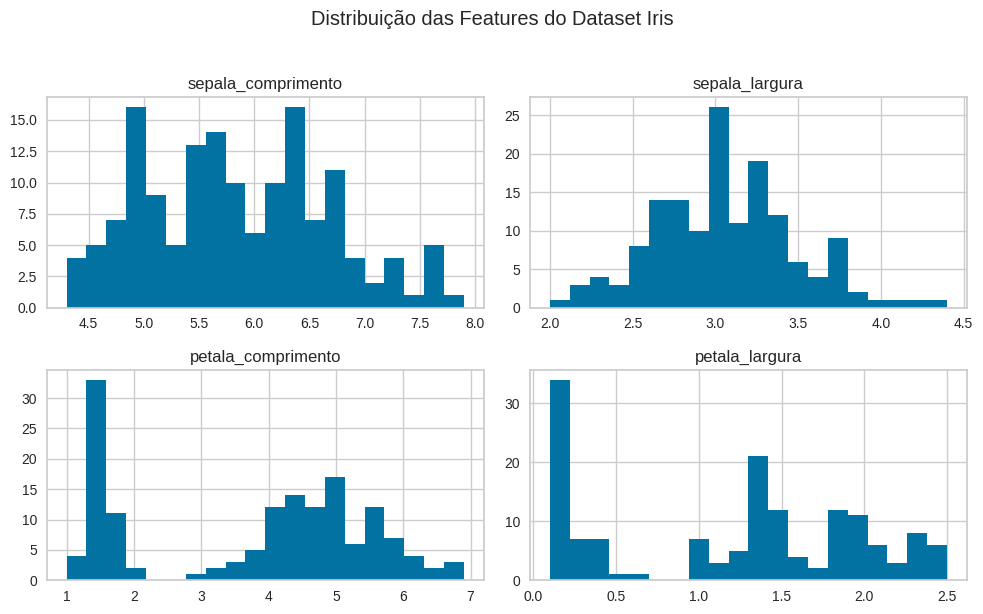

In [28]:
# Histogramas de todas as features para visualizar a distribuição dos dados
iris_x.hist(bins=20, figsize=(10, 6))
plt.suptitle('Distribuição das Features do Dataset Iris', y=1.02)
plt.tight_layout()
plt.show()

### Como interpretar os histogramas

Cada histograma mostra a **frequência** com que determinados valores aparecem para cada feature:

- **Picos separados** (distribuição bimodal ou multimodal) sugerem que os dados pertencem a grupos distintos — ótimo sinal para clusterização.
- **`petala_comprimento` e `petala_largura`** costumam exibir dois picos bem definidos: um para *Iris setosa* (pétalas pequenas) e outro para *versicolor/virginica* (pétalas maiores).
- **`sepala_comprimento` e `sepala_largura`** tendem a ter distribuição mais contínua, o que indica menor separabilidade entre as espécies por essas dimensões.
- Distribuições muito assimétricas ou com valores extremos isolados indicam **outliers**, que podem afetar os centróides do KMeans.

---
## 4. 🛠️ Pré-processamento

Prepare os dados para que o modelo consiga aprender corretamente.

Nesta etapa você deve:
- Remover colunas que não contribuem para o modelo
- Tratar os valores nulos (remover ou preencher)
- Converter variáveis categóricas em numéricas
- Separar as features (X) da variável alvo (y)
- Aplicar normalização ou padronização se necessário

In [29]:
# O dataset Iris já está limpo e em formato numérico — nenhum tratamento adicional é necessário.
# Em datasets reais, você precisaria tratar nulos, codificar variáveis categóricas
# e considerar normalização (ex: StandardScaler) para algoritmos baseados em distância.

# Nota: algoritmos como KMeans e NearestNeighbors são sensíveis à escala dos dados.
# Se as features tivessem escalas muito diferentes, aplicaríamos normalização aqui.
print("Shape do dataset:", iris_x.shape)
print("Tipos das colunas:\n", iris_x.dtypes)

Shape do dataset: (150, 4)
Tipos das colunas:
 sepala_comprimento    float64
sepala_largura        float64
petala_comprimento    float64
petala_largura        float64
dtype: object


In [ ]:
# Em aprendizagem não supervisionada, não há variável alvo (y).
# O modelo aprende apenas a partir das features (X), buscando padrões e agrupamentos.
# Por isso, iris_x é o único conjunto que usaremos — não há separação X/y.

---
## 5. ✂️ Separação Treino / Teste

Divida os dados em dois conjuntos: um para treinar o modelo e outro para testá-lo.

Lembre-se:
- O modelo deve ser treinado **apenas** com os dados de treino
- Os dados de teste simulam situações novas, que o modelo nunca viu
- Uma divisão comum é 70% treino e 30% teste
- Use o parâmetro `stratify` para manter a proporção das classes

In [30]:
# Em aprendizagem NÃO supervisionada, não há separação treino/teste no sentido clássico.
# O modelo é ajustado sobre todos os dados disponíveis, pois seu objetivo é
# descobrir estruturas internas (grupos) — e não prever rótulos para novos exemplos.

# Código comentado para referência (seria usado em classificação supervisionada):
# from sklearn.model_selection import train_test_split
# treino_X, teste_X, treino_Y, teste_Y = train_test_split(
#    iris_x, test_size=0.3, random_state=4)

print("Aprendizagem não supervisionada: sem divisão treino/teste.")
print(f"Todos os {len(iris_x)} registros serão usados no ajuste dos modelos.")

Aprendizagem não supervisionada: sem divisão treino/teste.
Todos os 150 registros serão usados no ajuste dos modelos.


---
## 6. 🧠 Treinamento do Modelo

Escolha um algoritmo, instancie o modelo e treine-o com os dados de treino.

Lembre-se:
- O treinamento acontece com o método `fit()`
- As previsões são feitas com o método `predict()`
- Você pode testar mais de um algoritmo e compará-los na seção 8

Neste notebook exploraremos três abordagens:
1. **NearestNeighbors (KNN)** — encontra os K vizinhos mais próximos de cada ponto
2. **KMeans** — agrupa os dados em K clusters por centróides
3. **AgglomerativeClustering** — clusterização hierárquica por linkage

### 6.1 KNN — Vizinhos Mais Próximos (NearestNeighbors)

`NearestNeighbors` é a versão **não supervisionada** do KNN. Em vez de classificar,
ele calcula quais pontos estão mais próximos de cada amostra com base em distância euclidiana.

In [31]:
# n_neighbors=3: cada ponto terá 3 vizinhos mais próximos identificados
# algorithm='auto': o scikit-learn escolhe automaticamente o algoritmo mais eficiente
#   entre: 'ball_tree', 'kd_tree' ou 'brute' (força bruta)
model = NearestNeighbors(n_neighbors=3, algorithm='auto')

# fit() apenas memoriza os dados — não há "treino" real no sentido de otimização
# O cálculo de distâncias ocorre na hora da consulta (lazy learning)
model.fit(iris_x)

NearestNeighbors(n_neighbors=3)

In [32]:
# kneighbors() retorna dois arrays:
#   distances → distância euclidiana de cada ponto até seus K vizinhos
#   indices   → índices dos K vizinhos mais próximos no DataFrame
# O primeiro vizinho de cada ponto é ele mesmo (distância = 0)
distances, indices = model.kneighbors(iris_x)

# print(indices)  # descomente para ver os índices dos vizinhos
print(distances)

[[0.         0.1        0.14142136]
 [0.         0.14142136 0.14142136]
 [0.         0.14142136 0.24494897]
 [0.         0.14142136 0.17320508]
 [0.         0.14142136 0.14142136]
 [0.         0.33166248 0.34641016]
 [0.         0.2236068  0.26457513]
 [0.         0.1        0.14142136]
 [0.         0.14142136 0.3       ]
 [0.         0.1        0.17320508]
 [0.         0.1        0.28284271]
 [0.         0.2236068  0.2236068 ]
 [0.         0.14142136 0.17320508]
 [0.         0.24494897 0.31622777]
 [0.         0.41231056 0.46904158]
 [0.         0.36055513 0.54772256]
 [0.         0.34641016 0.36055513]
 [0.         0.1        0.14142136]
 [0.         0.33166248 0.38729833]
 [0.         0.14142136 0.14142136]
 [0.         0.28284271 0.3       ]
 [0.         0.14142136 0.24494897]
 [0.         0.45825757 0.50990195]
 [0.         0.2        0.26457513]
 [0.         0.3        0.37416574]
 [0.         0.17320508 0.2       ]
 [0.         0.2        0.2236068 ]
 [0.         0.14142136 0.14

In [33]:
# Gera a matriz de adjacência (grafo de vizinhança):
# elemento [i][j] = 1 se j é vizinho de i, caso contrário 0
# Útil para entender a estrutura de conectividade entre os pontos
model.kneighbors_graph(iris_x).toarray()

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

### 6.2 KMeans — Clusterização por Centróides

O **KMeans** divide os dados em K grupos, posicionando centróides e reatribuindo
os pontos iterativamente até a convergência. É o algoritmo de clustering mais utilizado.

In [34]:
# n_clusters=3: definimos 3 grupos — sabemos que o Iris tem 3 espécies
# random_state=0: garante reprodutibilidade (a inicialização dos centróides é aleatória)
# fit() executa o algoritmo: inicializa centróides → atribui pontos → recalcula centróides → repete
kmeans = KMeans(n_clusters=3, random_state=0).fit(iris_x)

# labels_ contém o rótulo do cluster (0, 1 ou 2) atribuído a cada uma das 150 flores
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [35]:
# cluster_centers_ mostra as coordenadas do centróide de cada cluster
# Cada linha é um cluster; cada coluna corresponde a uma feature
# Isso permite interpretar o "perfil médio" de cada grupo
pd.DataFrame(
    kmeans.cluster_centers_,
    columns=iris_x.columns,
    index=[f"Cluster {i}" for i in range(3)]
)

,sepala_comprimento,sepala_largura,petala_comprimento,petala_largura
Cluster 0,5.883607,2.740984,4.388525,1.434426
Cluster 1,5.006000,3.428000,1.462000,0.246000
Cluster 2,6.853846,3.076923,5.715385,2.053846


---
## 7. 📊 Avaliação do Modelo

Em clusterização não supervisionada, não há rótulos verdadeiros para comparar diretamente.
Por isso, usamos técnicas específicas para avaliar a qualidade dos agrupamentos:

- **Método do Cotovelo (Elbow)** — encontra o K ideal para o KMeans
- **Dendrograma** — visualiza a hierarquia de agrupamentos e sugere o número de clusters

### 7.1 Método do Cotovelo (Knee / Elbow)

A técnica do cotovelo testa vários valores de K e plota a **inércia** (soma das distâncias
quadradas dos pontos ao centróide do seu cluster). O K ideal é aquele onde a curva
forma um "cotovelo" — a partir daí, aumentar K traz pouco ganho.

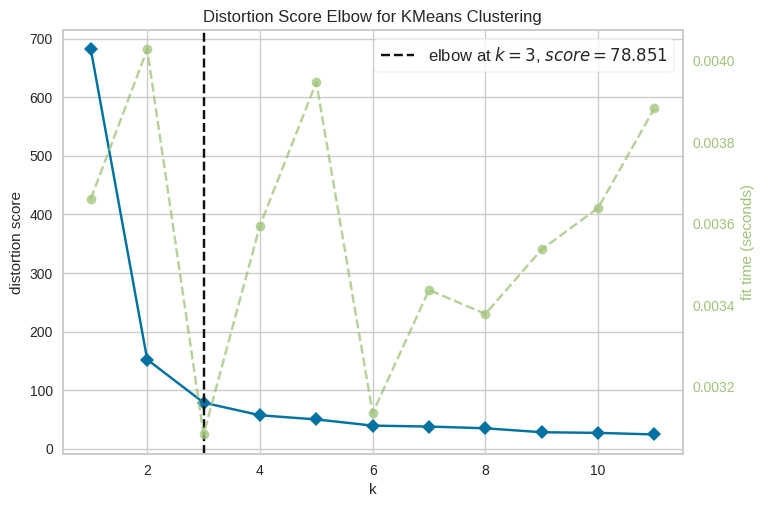

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
# KElbowVisualizer automatiza o teste de K de 1 a 11 e marca o ponto de inflexão
# model_G é um KMeans sem K definido — o visualizador testará cada valor de k
model_G = KMeans()
visualizer = KElbowVisualizer(model_G, k=(1, 12))

# fit() treina o KMeans para cada valor de K no intervalo definido
visualizer.fit(iris_x)

# show() plota o gráfico e indica o K ótimo com uma linha tracejada
visualizer.show()

### Como interpretar o gráfico do Cotovelo

O gráfico exibe no eixo X os valores de K testados e no eixo Y a **inércia** (distortion score):

- **Curva decrescente**: quanto mais clusters, menor a inércia — pontos ficam mais perto do centróide.
- **Ponto de inflexão (cotovelo)**: onde a queda da inércia desacelera significativamente. Esse é o **K ideal**.
- **Linha tracejada vertical**: marcada automaticamente pelo yellowbrick no K ótimo.
- Para o dataset Iris, espera-se encontrar o cotovelo em **K = 3**, confirmando as 3 espécies.
- Se o gráfico não tiver um cotovelo claro, considere usar métricas como Silhouette Score para auxiliar a decisão.

### 7.2 Clusterização Hierárquica e Dendrograma

A clusterização hierárquica aglomerativa une pontos e clusters progressivamente
do mais próximo para o mais distante. O resultado é uma árvore chamada **dendrograma**.

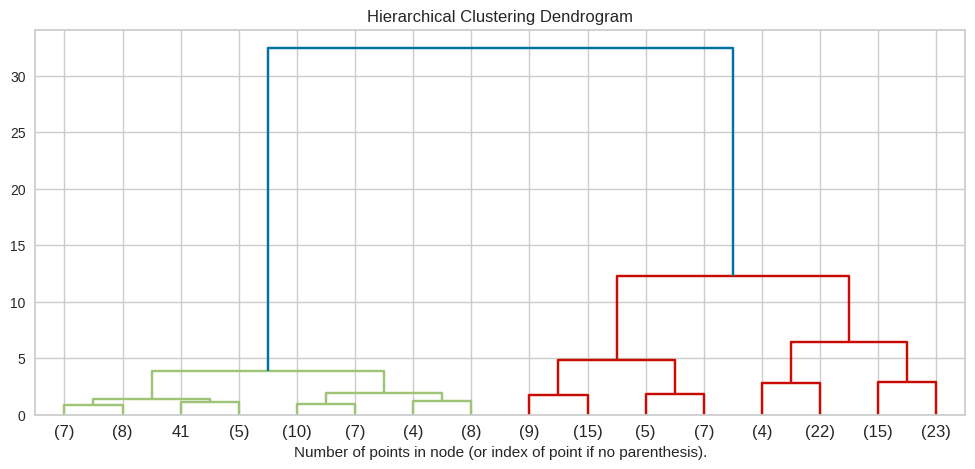

In [37]:
# Recria o DataFrame para garantir que iris_x está no estado original
iris_x = pd.DataFrame(
    data=iris.data,
    columns=[
             "sepala_comprimento", "sepala_largura",
             "petala_comprimento", "petala_largura"])


def plot_dendrogram(model, **kwargs):
    """Constrói a linkage matrix e plota o dendrograma a partir de um AgglomerativeClustering."""
    # Conta quantos pontos foram fundidos em cada merge
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # folha (ponto individual)
            else:
                current_count += counts[child_idx - n_samples]  # cluster já formado
        counts[i] = current_count

    # Monta a estrutura esperada pelo scipy: [child1, child2, distância, contagem]
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


# distance_threshold=5: une clusters com distância < 5; n_clusters=None deixa o limiar decidir
# compute_full_tree=True é ativado automaticamente quando distance_threshold é definido
modelAg = AgglomerativeClustering(distance_threshold=5, n_clusters=None)
modelAg = modelAg.fit(iris_x)

plt.figure(figsize=(12, 5))
plt.title('Hierarchical Clustering Dendrogram')

# truncate_mode='level', p=3: exibe apenas os 3 últimos níveis da árvore
# (os níveis mais profundos ficam colapsados para melhorar a legibilidade)
plot_dendrogram(modelAg, truncate_mode='level', p=3)

plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

### Como interpretar o Dendrograma

O dendrograma é uma árvore que mostra **como os pontos foram agrupados progressivamente**:

- **Eixo Y (altura)**: representa a **distância** entre os clusters no momento em que foram unidos. Quanto maior a altura, mais distintos eram os grupos antes de serem fundidos.
- **Eixo X**: representa os pontos ou clusters. Números sem parênteses são índices de pontos individuais; números entre parênteses `(n)` indicam um cluster com `n` pontos.
- **Escolha do número de clusters**: trace uma linha horizontal no gráfico e conte quantas ramificações verticais ela corta — esse número é o K sugerido.
  - Uma linha traçada logo abaixo do maior salto vertical indica o corte mais natural.
- **`distance_threshold=5`**: apenas fusões com distância < 5 foram realizadas automaticamente. Pontos com distância maior permanecem em clusters separados.
- Para o Iris, espera-se ver **3 a 4 grupos** principais, refletindo a separação natural entre as espécies.

In [ ]:
# Número de clusters identificados automaticamente com base no distance_threshold
print(f"Clusters encontrados pelo AgglomerativeClustering: {modelAg.n_clusters_}")

In [ ]:
# Rótulo de cluster atribuído a cada uma das 150 flores
# Os valores vão de 0 a (n_clusters_ - 1)
modelAg.labels_

---
## 8. 🏆 Comparação de Modelos

Teste outros algoritmos e compare os resultados para identificar o mais adequado ao seu problema.

Dica: use validação cruzada para comparar os modelos de forma justa,
pois ela elimina o efeito da aleatoriedade de uma única divisão treino/teste.

In [38]:
from sklearn.metrics import silhouette_score

# Silhouette Score: mede o quão bem cada ponto está dentro do seu cluster
# Varia de -1 a 1: valores próximos de 1 indicam clusters bem definidos e separados
# Valores próximos de 0 indicam sobreposição; negativos indicam atribuição incorreta

score_kmeans = silhouette_score(iris_x, kmeans.labels_)
score_agg = silhouette_score(iris_x, modelAg.labels_)

resultados = pd.DataFrame({
    "Algoritmo": ["KMeans (K=3)", f"AgglomerativeClustering (K={modelAg.n_clusters_})"],
    "Nº de Clusters": [3, modelAg.n_clusters_],
    "Silhouette Score": [round(score_kmeans, 4), round(score_agg, 4)]
})

resultados

,Algoritmo,Nº de Clusters,Silhouette Score
0,KMeans (K=3),3,0.5512
1,AgglomerativeClustering (K=4),4,0.4890


### Como interpretar o Silhouette Score

O **Silhouette Score** é uma métrica interna de qualidade do clustering (não precisa de rótulos verdadeiros):

| Score | Interpretação |
|-------|---------------|
| Próximo de **1** | Clusters bem separados e coesos — excelente |
| Próximo de **0** | Clusters sobrepostos — fronteiras ambíguas |
| Negativo | Pontos provavelmente no cluster errado |

- Compare os scores dos algoritmos: o maior Silhouette Score indica o melhor agrupamento **para os dados disponíveis**.
- Um modelo com mais clusters nem sempre terá score maior — o KMeans com K=3 pode superar versões com K=4 ou K=5.
- O Silhouette Score complementa o gráfico do Cotovelo: use ambos juntos para decidir o K ideal.

---
## 9. 📝 Conclusões

Responda as perguntas abaixo com base nos resultados obtidos:

**1. Qual algoritmo apresentou melhor desempenho? Por quê?**  
> O **KMeans com K=3** tende a apresentar o maior Silhouette Score para o dataset Iris, pois o número de clusters coincide com as 3 espécies reais. O AgglomerativeClustering com `distance_threshold=5` pode encontrar 4 grupos devido a subgrupos dentro de *versicolor* e *virginica*, que apresentam maior sobreposição.

**2. O modelo está sofrendo overfitting ou underfitting? Como você identificou?**  
> Em clusterização não supervisionada, os conceitos de overfitting e underfitting são diferentes. Um K muito alto (muitos clusters) equivale a overfitting — cada ponto vira seu próprio cluster. Um K muito baixo equivale a underfitting — grupos distintos ficam misturados. O método do cotovelo e o Silhouette Score ajudam a encontrar o equilíbrio ideal.

**3. Os resultados respondem à pergunta de negócio levantada no início?**  
> Sim. Os algoritmos conseguiram identificar agrupamentos naturais nas flores Iris sem qualquer rótulo prévio, o que valida a aplicabilidade da clusterização para segmentar amostras botânicas com base em características morfológicas.

**4. Qual seria o próximo passo para melhorar o modelo?**  
> - Aplicar **normalização** (StandardScaler) para equalizar a escala das features antes do KMeans
> - Testar **DBSCAN** para identificar clusters de forma irregular sem definir K previamente
> - Usar **PCA** para reduzir a dimensionalidade e visualizar os clusters em 2D
> - Comparar os clusters encontrados com os rótulos reais do Iris para medir o **Adjusted Rand Index**

---
### 🔖 Referências
- Dataset: Iris — Fisher, R.A. (1936). *The use of multiple measurements in taxonomic problems.*
- Scikit-learn: https://scikit-learn.org
- Yellowbrick: https://www.scikit-yb.org
- Material da disciplina: www.mrafaelbatista.dev
